In [ ]:
import importlib
from pathlib import Path
from torch.utils.data import Sampler, DataLoader, random_split
import torch
import matplotlib.pyplot as plt

In [2]:
from functions_library import *

In [70]:
importlib.reload(dataset_classes)

<module 'functions_library.dataset_classes' from 'c:\\Users\\jonas\\Desktop\\Masters\\Main\\Masters_project\\functions_library\\dataset_classes.py'>

In [5]:
notebook_dir = Path.cwd()
for paths in notebook_dir.parents[0].iterdir():
    if paths.suffix == ".npy":
        file_path = paths
        break
file_path

WindowsPath('c:/Users/jonas/Desktop/Masters/Main/output.npy')

In [23]:
sizes = [2**i for i in range(6, 19)]
sizes

[64,
 128,
 256,
 512,
 1024,
 2048,
 4096,
 8192,
 16384,
 32768,
 65536,
 131072,
 262144]

In [26]:
dataset = dataset_classes.npyDataset(file_path)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42))


train_loader = DataLoader(train_dataset, batch_size=8192, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=8192, shuffle=False, num_workers=0)
model = neural_models.NeuralNetwork(input_size=dataset.features.shape[1], hidden_sizes=[64, 32], output_size=1)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_function = torch.nn.MSELoss()
model, train_losses, val_losses = model_training.train_model(model, optimizer, loss_function, train_loader, val_loader, num_epochs=10, device='cpu')


Epoch 1/10, Training Loss: 1515696662.6032, Validation Loss: 1457227874.5773
Epoch 2/10, Training Loss: 1281487984.8654, Validation Loss: 1031614389.0475
Epoch 3/10, Training Loss: 744898474.3952, Validation Loss: 488587150.1321
Epoch 4/10, Training Loss: 388175343.7147, Validation Loss: 336423958.6014
Epoch 5/10, Training Loss: 331734690.2226, Validation Loss: 322841276.7284
Epoch 6/10, Training Loss: 321762621.7042, Validation Loss: 314060114.9781
Epoch 7/10, Training Loss: 313774196.3990, Validation Loss: 306971708.3510
Epoch 8/10, Training Loss: 307738461.0108, Validation Loss: 301907807.9924
Epoch 9/10, Training Loss: 303423008.1332, Validation Loss: 298159980.4555
Epoch 10/10, Training Loss: 300020579.4410, Validation Loss: 295626697.0849


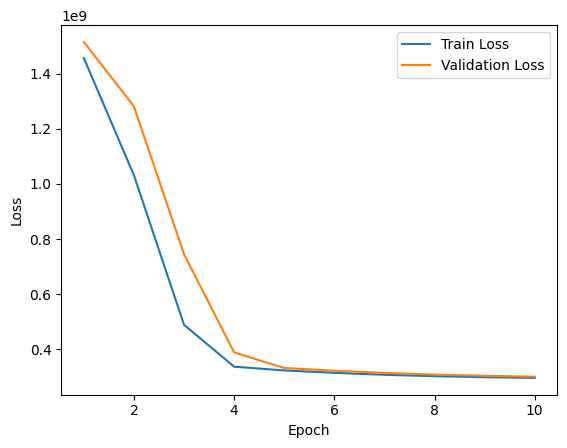

In [28]:
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Train Loss')
plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

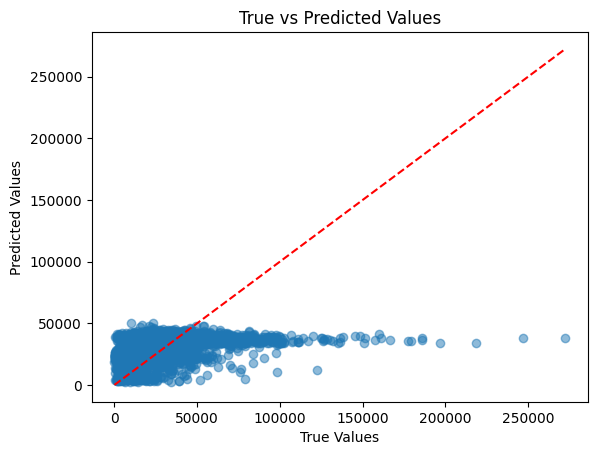

In [33]:
#y_pred = model_training.predict_model(model, val_loader, device='cpu')
#y_true = torch.cat([targets for _, targets in val_loader], dim=0).numpy()
model.eval()
x, y_true = next(iter(val_loader))
y_pred = model(x).detach().numpy()

plt.scatter(y_true, y_pred, alpha=0.5)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')  # Diagonal line
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('True vs Predicted Values')
plt.show()

In [3]:
notebook_dir = Path.cwd()
h5_dirs_path = notebook_dir.parent / "h5"

# Choose two folders from the same particle type and simulation category.
source_1_dir = h5_dirs_path / "MC_EGAM1"
source_2_dir = h5_dirs_path / "MC_EGAM7"


def data_category(path):
    name = path.name.upper()
    particle = "MUONS" if "MUON" in name else "EGAM" if "EGAM" in name else None
    simulation = "DATA" if name.startswith("DATA_") else "MC" if name.startswith("MC_") else None
    if particle is None or simulation is None:
        raise ValueError(
            f"Cannot determine particle/simulation category from folder name: {path.name}"
        )
    return particle, simulation


if data_category(source_1_dir) != data_category(source_2_dir):
    raise ValueError(
        "Cannot mix folders with different particle types or categories: "
        f"{source_1_dir.name} and {source_2_dir.name}"
    )

h5_files_1 = sorted(
    path for path in source_1_dir.iterdir() if path.is_file() and path.suffix == ".h5"
)
h5_files_2 = sorted(
    path for path in source_2_dir.iterdir() if path.is_file() and path.suffix == ".h5"
)

if not h5_files_1:
    raise FileNotFoundError(f"No files found in {source_1_dir}")
if not h5_files_2:
    raise FileNotFoundError(f"No files found in {source_2_dir}")

print(f"Mixing {source_1_dir.name} with {source_2_dir.name}")

Mixing MC_EGAM1 with MC_EGAM7


In [120]:
import h5py
file = h5py.File(h5_files_1[0], 'r')
file["truth"][0]

np.void((17955.262, 0.009705276, -2.9661877, 17956.107, 0.5109989), dtype=[('pt', '<f4'), ('eta', '<f4'), ('phi', '<f4'), ('e', '<f4'), ('m', '<f4')])

In [129]:
n_egammas = file["eventwise"]["nEgammas"]
indexes = file["eventwise"]["firstEgammaIndex"]
origin = file["egammas"]["truthOrigin"]
type_ = file["egammas"]["truthType"]
energy = file["truth"]["pt"]

batch_size = 1024
ori_num = 13
type_num = 2

batches = len(indexes)//batch_size
energies = []
for i in range(batches):
    ns = n_egammas[i*batch_size:min((i+1)*batch_size, len(n_egammas))]
    index = indexes[i*batch_size:min((i+1)*batch_size, len(indexes))]

    index = index[ns > 0]
    ns = ns[ns > 0]

    n_1_i = index[ns == 1]
    ori_mask = origin[n_1_i] == ori_num
    type_mask = type_[n_1_i] == type_num
    sort_mask = np.logical_and(ori_mask, type_mask)
    energies.extend(energy[n_1_i[sort_mask]].tolist())
    index_left = index[ns > 1]
    n_left = ns[ns > 1]
    for indies, n in zip(index_left, n_left):
        E = 0
        for j in range(indies, indies + n):
            if origin[j] == ori_num and type_[j] == type_num:
                E += energy[j]
        if E > 0:
            energies.append(E)
    print(f"Batch {i+1}/{batches} processed. Total energies collected: {len(energies)}", end="\r")

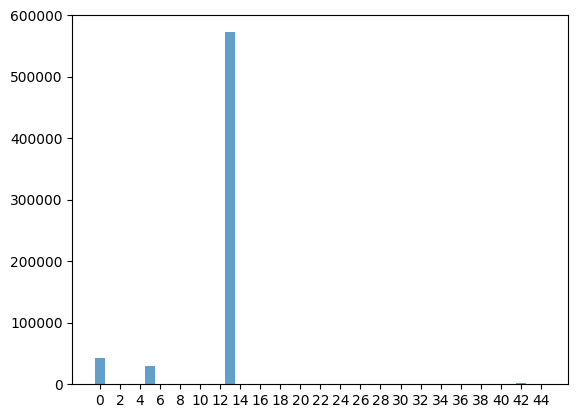

In [126]:
plt.hist(file["egammas"]["truthOrigin"], bins=np.arange(-0.5, 45, 1), alpha=0.7)
plt.xticks(np.arange(0, 45, 2))
plt.show()

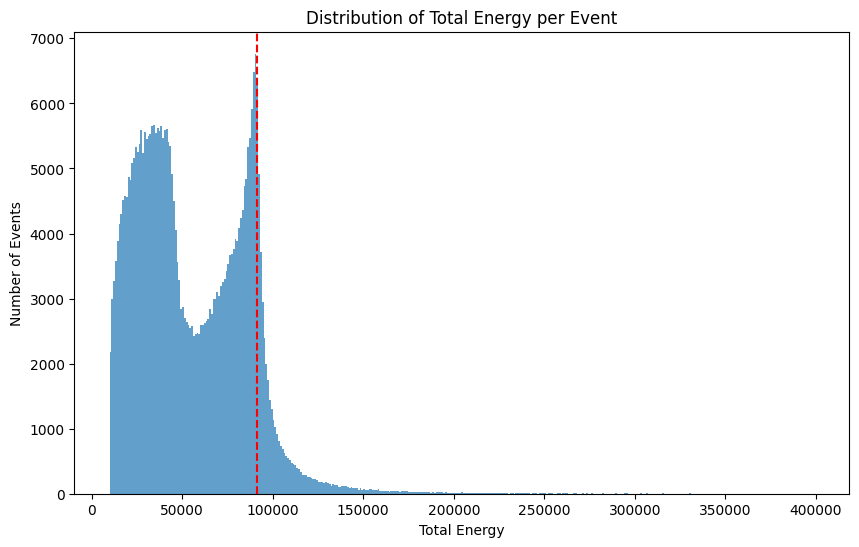

In [130]:
plt.figure(figsize=(10, 6))
plt.hist(energies, bins=np.arange(10000, 400000, 1000), alpha=0.7)
plt.axvline(x=91180, color='r', linestyle='--')
plt.title("Distribution of Total Energy per Event")
plt.xlabel("Total Energy")
plt.ylabel("Number of Events")
plt.show()

In [ ]:
dataset = dataset_classes.H5EgammaDataset_fully_batched(
    h5_files_1,
    exclude_features = [],
    exclude_fields = [],
)
sampler = data_loading.ShuffledContiguousBatchSampler(len(dataset), batch_size=1024)
loader = DataLoader(dataset, batch_sampler=sampler, num_workers=8, prefetch_factor=2, persistent_workers=True, pin_memory=True)

In [12]:
import time

for workers in [2, 4, 6, 8]:
    for prefetch_factor in [2, 4, 6, 8]:
        loader = DataLoader(
            dataset,
            batch_sampler=sampler,
            num_workers=workers,
            prefetch_factor=prefetch_factor,
            persistent_workers=workers > 0,
            pin_memory=True,
        )

        start = time.perf_counter()

        for batch_number, (inputs, targets) in enumerate(loader):
            if batch_number == 5:
                start = time.perf_counter()  # Reset the timer after the first 5 batches
            if batch_number == 20:
                break

        elapsed = time.perf_counter() - start
        print(f"num_workers={workers}, prefetch_factor={prefetch_factor}: {elapsed:.2f} seconds")

num_workers=2, prefetch_factor=2: 25.46 seconds
num_workers=2, prefetch_factor=4: 21.88 seconds
num_workers=2, prefetch_factor=6: 26.84 seconds
num_workers=2, prefetch_factor=8: 25.10 seconds
num_workers=4, prefetch_factor=2: 15.24 seconds
num_workers=4, prefetch_factor=4: 17.70 seconds
num_workers=4, prefetch_factor=6: 15.57 seconds
num_workers=4, prefetch_factor=8: 18.21 seconds
num_workers=6, prefetch_factor=2: 14.45 seconds
num_workers=6, prefetch_factor=4: 12.23 seconds
num_workers=6, prefetch_factor=6: 16.79 seconds
num_workers=6, prefetch_factor=8: 15.54 seconds
num_workers=8, prefetch_factor=2: 9.84 seconds
num_workers=8, prefetch_factor=4: 15.94 seconds
num_workers=8, prefetch_factor=6: 13.87 seconds
num_workers=8, prefetch_factor=8: 11.48 seconds


In [66]:
325*15

4875

In [65]:
X.shape

torch.Size([1024, 6958])

In [32]:
mem = X.nelement() * X.element_size()  # Total memory in bytes
print(f"Total memory used by the batch: {mem / (1024 ** 2):.2f} MB")

Total memory used by the batch: 217.44 MB


In [19]:
data_loading.h5_to_npy(h5_files_1, "output.npy", y_source = "truth", y_field="pt", include_features=["egammas"], include_fields=["eta", "charge", "ptcone20", "z0", "d0", "passid_Loose"], sample_size=10000)

Converting H5 files in [WindowsPath('c:/Users/jonas/Desktop/Masters/Main/h5/MC_EGAM1/user.amoranch.50640148._000003.output.h5'), WindowsPath('c:/Users/jonas/Desktop/Masters/Main/h5/MC_EGAM1/user.amoranch.50640148._000013.output.h5'), WindowsPath('c:/Users/jonas/Desktop/Masters/Main/h5/MC_EGAM1/user.amoranch.50640148._000023.output.h5'), WindowsPath('c:/Users/jonas/Desktop/Masters/Main/h5/MC_EGAM1/user.amoranch.50640148._000042.output.h5'), WindowsPath('c:/Users/jonas/Desktop/Masters/Main/h5/MC_EGAM1/user.amoranch.50640148._000045.output.h5'), WindowsPath('c:/Users/jonas/Desktop/Masters/Main/h5/MC_EGAM1/user.amoranch.50640148._000049.output.h5'), WindowsPath('c:/Users/jonas/Desktop/Masters/Main/h5/MC_EGAM1/user.amoranch.50640148._000054.output.h5'), WindowsPath('c:/Users/jonas/Desktop/Masters/Main/h5/MC_EGAM1/user.amoranch.50640148._000063.output.h5'), WindowsPath('c:/Users/jonas/Desktop/Masters/Main/h5/MC_EGAM1/user.amoranch.50640148._000064.output.h5'), WindowsPath('c:/Users/jonas/Des

TypeError: argument should be a str or an os.PathLike object where __fspath__ returns a str, not 'list'

In [75]:
x, y = next(iter(loader))

In [18]:
x.shape

torch.Size([1024, 6958])